In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random
import numpy as np

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20
}

# ★ residue_depth 추가해서 20차원으로 고정
DEFAULT_STRUCT_NAMES = [
    "plddt_center","plddt_neigh_mean","plddt_neigh_min","plddt_neigh_max",
    "msf_center","msf_neigh_mean",
    "lrco",
    "d_volume","d_hydropathy","d_charge",
    "ddg_fold",
    "sin_phi","cos_phi","sin_psi","cos_psi",
    "gly_switch","pro_switch", "delta_psic","shannon"
]
S_DIM = len(DEFAULT_STRUCT_NAMES) 

def random_voxel_rotate(voxel):
    if random.random() < 0.5:
        axes = [(2, 3), (1, 3), (1, 2)]
        k = random.choice([1, 2, 3])
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, struct_cache_dir, aug=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.struct_cache_dir = struct_cache_dir
        self.aug = aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = row["MutPos"]
        wt = row["WT"]
        mut = row["Mut"]
        label = row["Label"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # (1, 7, 7, 7, 63)

        feature_tensor = (
            torch.from_numpy(feature)
                 .permute(0, 4, 1, 2, 3)  # → (1, 63, 7, 7, 7)
                 .float()
                 .squeeze(0)              # → (63, 7, 7, 7)
        )

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)

        key_S = f"{uid}_{int(mut_pos)}_{wt.upper()}{mut.upper()}"
        struct_path = os.path.join(self.struct_cache_dir, f"{key_S}.pkl")
        
        if os.path.exists(struct_path):
            with open(struct_path, "rb") as f:
                S = pickle.load(f)["S"]  # np.array, (S_dim,)
        else:
            S = np.zeros(S_DIM, dtype=np.float32)  
            print(f"[struct missing] {key_S} → zeros({S_DIM})")

        # ★ 길이 불일치 방어(패딩/절단)
        if S.shape[0] != S_DIM:
            old = S.shape[0]
            if S.shape[0] < S_DIM:
                S = np.pad(S, (0, S_DIM - S.shape[0]), constant_values=np.nan)
            else:
                S = S[:S_DIM]
            print(f"[struct size fix] {key_S}: {old} -> {S_DIM}")

        S_tensor = torch.from_numpy(np.asarray(S, dtype=np.float32))

        # NaN 디버그 프린트
        if torch.isnan(S_tensor).any():
            nan_idx = torch.isnan(S_tensor).nonzero(as_tuple=False).view(-1).tolist()
            nan_names = [DEFAULT_STRUCT_NAMES[i] if i < S_DIM else f"f{i}" for i in nan_idx]
            print(f"[NaN in S] {uid}:{mut_pos} {wt}->{mut} | idx={nan_idx} | names={nan_names} | path={struct_path}")

        S_tensor = torch.nan_to_num(S_tensor, nan=0.0)

        ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
        mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)

        return feature_tensor, S_tensor, ref_idx, mut_idx, torch.tensor(label).float()

class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2
        self.aug = aug
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = int(row["MutPos"]) - 1
        label = float(row["Label"])
        mut = row["Mut"].upper()

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]

        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        seqs_to_use = [mut_seq, list(query_seq)]
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]
            random.shuffle(msa_part)
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                aa = seq[seq_idx] if 0 <= seq_idx < len(seq) else '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)                           # [L, D]

        return {"msa": msa_tensor, "label": torch.tensor(label).float()}

class MultimodalDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, struct_cache_dir, msa_dict_path, 
                 voxel_aug=False, msa_aug=False, max_depth=80, win_size=61):
        self.df = df.reset_index(drop=True)
        self.voxel_dataset = VoxelDataset(df, voxel_cache_dir, struct_cache_dir, aug=voxel_aug)
        self.msa_dataset = MSADataset(df, msa_dict_path, max_depth=max_depth, win_size=win_size, aug=msa_aug)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        voxel_feat, s_tensor, ref_idx, mut_idx, label = self.voxel_dataset[idx]
        msa_data = self.msa_dataset[idx]
        msa_tensor = msa_data["msa"]
        # assert float(label) == float(msa_data["label"]), "Mismatch in label!"

        return {
            "voxel": voxel_feat,      # [63, 7, 7, 7]
            "s_tensor": s_tensor,     # [20]
            "ref_idx": ref_idx,
            "mut_idx": mut_idx,
            "msa": msa_tensor,        # [L=61, D]
            "label": label
        }


In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
import torch.nn.functional as F
import numpy as np

# --- Input Embedding ---
class MSAInputEmbedding(nn.Module):
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x):  # x: (B, L, D)
        return self.embedding(x)  # → (B, L, D, C)

# --- Cross-Axial Mamba Block ---
class CrossAxialMambaMSA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_L = nn.RMSNorm(dim, eps=1e-8)
        self.norm_D = nn.RMSNorm(dim, eps=1e-8)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=5, padding=2),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2  # = 30

        # --- D-axis: only at center L position ---
        x_d_center = self.norm_D(x[:, center_L])  # (B, D, C)
        x_d = x_d_center.transpose(1, 2)          # (B, C, D)
        d_out = self.conv_D(x_d).transpose(1, 2).unsqueeze(1)  # (B, 1, D, C)

        # --- L-axis: full Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3)  # (B, L, D, C)

        # --- Residual ---
        # d_out is only for center, rest is zero
        d_full = torch.zeros_like(x)
        d_full[:, center_L:center_L+1] = d_out

        return x + d_full + l_out
    
# # --- Encoder ---
class MSAEncoder(nn.Module):
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = nn.RMSNorm(dim, eps=1e-8)

    def forward(self, x):  # x: (B, L, D)
        x = self.embeddings(x)  # → (B, L, D, C)
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  # (B, L, D, C)


class SqueezeExcitation3D(nn.Module):
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(self.pool(x))
        return x * scale

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=16):
        super().__init__()
        mid_ch = in_ch * expand_ratio

        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)

        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            return out + identity
        else:
            return out

import torch
import torch.nn as nn
import torch.nn.functional as F

class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt3D(nn.Module):
    def __init__(self, inp, oup, reduction=16):
        super().__init__()
        # 축별 pooling
        self.pool_d = nn.AdaptiveAvgPool3d((None, 1, 1))  # keep D
        self.pool_h = nn.AdaptiveAvgPool3d((1, None, 1))  # keep H
        self.pool_w = nn.AdaptiveAvgPool3d((1, 1, None))  # keep W

        mip = max(8, inp // reduction)

        self.conv1 = nn.Conv3d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm3d(mip)
        self.act = h_swish()

        # 축별 복원 conv
        self.conv_d = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_h = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        B, C, D, H, W = x.size()

        # --- 축별 pooling ---
        x_d = self.pool_d(x)  # [B,C,D,1,1]
        x_h = self.pool_h(x)  # [B,C,1,H,1]
        x_w = self.pool_w(x)  # [B,C,1,1,W]

        # 축 정렬을 위해 permute
        x_h = x_h.permute(0, 1, 3, 2, 4)  # [B,C,H,1,1]
        x_w = x_w.permute(0, 1, 4, 2, 3)  # [B,C,W,1,1]

        # concat along "length" dimension
        y = torch.cat([x_d, x_h, x_w], dim=2)  # [B,C,D+H+W,1,1]
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)

        # 다시 split
        x_d, x_h, x_w = torch.split(y, [D, H, W], dim=2)

        # 축 되돌리기
        x_h = x_h.permute(0, 1, 3, 2, 4)  # [B,C,1,H,1]
        x_w = x_w.permute(0, 1, 3, 4, 2)  # [B,C,1,1,W]

        # attention map
        a_d = self.conv_d(x_d).sigmoid()  # [B,C,D,1,1]
        a_h = self.conv_h(x_h).sigmoid()  # [B,C,1,H,1]
        a_w = self.conv_w(x_w).sigmoid()  # [B,C,1,1,W]

        out = identity * a_d * a_h * a_w
        return out

    
class VoxelBranch(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128):
        super().__init__()
        
        # 3D 구조 백본
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 32, expand_ratio=6),     # [7×7×7]
            MBConv3D(32, 32, expand_ratio=6),
            MBConv3D(32, 48, expand_ratio=6),
            MBConv3D(48, 48, expand_ratio=6),
            MBConv3D(48, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6, stride=2),  # 다운샘플링: → [4×4×4]
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6)
        )

        self.coordatt = CoordAtt3D(emb_dim, emb_dim)

        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]

        # Mutation Embedding (64 + 64 → 128)
        self.ref_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_fusion = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

        self.refine = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

    def forward(self, x, ref_idx, mut_idx):
        x = self.backbone(x)               # [B, 128, 7, 7, 7]
        x = self.coordatt(x) 
        x = self.pool(x).squeeze(-1).squeeze(-1).squeeze(-1)  # → [B, 128]

        # Mutation embedding
        ref_vec = self.ref_emb(ref_idx)    # [B, 64]
        mut_vec = self.mut_emb(mut_idx)    # [B, 64]
        mut_feat = self.mut_fusion(torch.cat([ref_vec, mut_vec], dim=1))  # [B, 128]

        # Combine structure & mutation features
        x = x + mut_feat                   # [B, 128]

        return self.refine(x)       # [B, 128]


class CenterAwarePooling(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2

        # Query: center residue [B,D,C] → [B*D,1,C]
        query = x[:, center_L].reshape(B * D, 1, C)

        # Key/Value: 전체 window [B,L,D,C] → [B*D,L,C]
        keyval = x.permute(0, 2, 1, 3).reshape(B * D, L, C)

        # Attention
        attn_out, _ = self.attn(query, keyval, keyval)  # [B*D,1,C]

        # Depth 방향 평균 → [B,C]
        pooled = attn_out.view(B, D, C).mean(dim=1)
        return pooled
    
class MSABranch(nn.Module):
    def __init__(self, num_layers=4, dim=128):
        super().__init__()
        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)
        self.pooling = CenterAwarePooling(dim, num_heads=4)

        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B,L,D)
        x = self.encoder(x)        # [B,L,D,C]
        x = self.pooling(x)        # [B,C]  ← center+context 반영
        return self.refine(x)      # [B,C]
    
class EvoStructCLIP(nn.Module):
    def __init__(self, voxel_ch=63, mb_layers=8, embed_dim=128, use_concat=True, dropout_p=0.3):
        super().__init__()
        self.voxel_encoder = VoxelBranch(in_ch=voxel_ch, emb_dim=embed_dim)
        self.msa_encoder = MSABranch(num_layers=mb_layers, dim=embed_dim)
        self.use_concat = use_concat

        # log(1 / 0.07) ≈ 2.6592 → exp(logit_scale) ≈ 14.2857
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        fused_dim = embed_dim * 2 if use_concat else embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.SiLU(),
            # nn.Dropout(dropout_p),
            nn.Linear(embed_dim, 1)
        )

    def _get_vector_norm(self, tensor):
        return F.normalize(tensor, dim=-1, eps=1e-8)

    def forward(self, voxel, ref_idx, mut_idx, msa):
        # Raw features
        voxel_feat = self.voxel_encoder(voxel, ref_idx, mut_idx)  # [B, 128]
        msa_feat = self.msa_encoder(msa)                          # [B, 128]

        voxel_embeds = F.normalize(voxel_feat, dim=-1, eps=1e-8)
        msa_embeds   = F.normalize(msa_feat, dim=-1, eps=1e-8)

        logits_per_voxel = torch.matmul(voxel_embeds, msa_embeds.t().to(voxel_embeds.device))
        logits_per_voxel = logits_per_voxel * self.logit_scale.exp().to(voxel_embeds.device)

        logits_per_msa = logits_per_voxel.t() 

        # For classification
        fused = torch.cat([voxel_feat, msa_feat], dim=-1) if self.use_concat else voxel_feat + msa_feat
        logits = self.classifier(fused)

        return {
            "logits": logits,
            "logits_per_msa": logits_per_msa,
            "logits_per_voxel": logits_per_voxel,
            "voxel_feat": voxel_feat,
            "msa_feat": msa_feat
        }

/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd

df = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/PTEN_TPMT_VAMPseq_combined_filtering.tsv", sep="\t")

from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.05, random_state=42) 


voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_4_PTEN_TPMT_noRSA"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid.pkl"
struct_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/struct_feature_cache_PTEN_TPMT_3"

train_dataset = MultimodalDataset(df_train, voxel_cache_dir, struct_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False)
val_dataset   = MultimodalDataset(df_val, voxel_cache_dir, struct_cache_dir, msa_dict_path)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [4]:
import numpy as np
import torch
from scipy.stats import pearsonr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=46, mb_layers=6, embed_dim=128, use_concat=True, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250903_clip.pth"))
model.eval()

@torch.no_grad()
def collect_meta_features(model, loader, device):
    model.eval()
    X_list, y_list = [], []
    for batch in loader:
        voxel   = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa     = batch["msa"].to(device)
        S       = batch["s_tensor"].to(device)      # [B,19]
        y       = batch["label"].float().to(device) # [B] or [B,1]

        out     = model(voxel, ref_idx, mut_idx, msa)
        voxel_feat = out["voxel_feat"].cpu().numpy()   # [B,128]
        msa_feat = out["msa_feat"].cpu().numpy()     # [B,128]
        fused_feat = np.concatenate([voxel_feat, msa_feat], axis=1)  # [B,256]

        S_np    = S.cpu().numpy()                              # [B,19]

        X = np.concatenate([S_np, fused_feat], axis=1)              # [B,20]
        
        y = y.view(-1).cpu().numpy()
        X_list.append(X); y_list.append(y)

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    return X_all, y_all

# 수집
X_tr, y_tr = collect_meta_features(model, train_loader, device)
X_va, y_va = collect_meta_features(model, val_loader, device)
print("train X:", X_tr.shape, "val X:", X_va.shape)  # (N, 256 + 19), (M, 256 + 19)

train X: (7410, 275) val X: (391, 275)


In [5]:
del model
torch.cuda.empty_cache()

In [6]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr
import numpy as np
import joblib
import pandas as pd

# ========================
# 1. 데이터 준비
# ========================
# X_tr, y_tr, X_va, y_va 는 이미 준비된 상태라고 가정

# Pearson r 스코어러
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

# ========================
# 2. 하이퍼파라미터 탐색 (CPU)
# ========================
base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=1
)

param_distributions = {
    "n_estimators":   np.linspace(800, 6000, 30, dtype=int),
    "learning_rate":  np.logspace(-4.5, -1, 30),
    "max_depth":      [3, 4, 5, 6, 7, 8],
    "min_child_weight":[1, 2, 3, 5, 8, 10, 15],
    "subsample":      [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.4, 0.5, 0.6, 0.7, 0.9, 1.0],
    "reg_lambda":     [0.01, 0.1, 1.0, 5.0, 10.0, 30.0],
    "reg_alpha":      [0.0, 0.1, 1.0, 5.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=1,
    verbose=2,
    refit=False,
    random_state=42
)
search.fit(X_tr, y_tr)

best_params = {k: (int(v) if isinstance(v, np.integer) else
                   float(v) if isinstance(v, np.floating) else v)
               for k, v in search.best_params_.items()}
print("Best CV Pearson r:", search.best_score_)
print("Best params:", best_params)

# ========================
# 3. 단일 Best 모델 학습 (GPU)
# ========================
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
    **best_params
)
best_xgb.fit(X_tr, y_tr)

# 저장
joblib.dump(best_xgb, "best_xgb_model_0905.pkl")
print("✅ 단일 모델 저장 완료: best_xgb_model_0905.pkl")

# ========================
# 4. CV 앙상블 학습 & 저장
# ========================
def train_cv_models(X, y, params, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    models = []
    for train_idx, test_idx in kf.split(X):
        X_train, y_train = X[train_idx], y[train_idx]
        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=seed,
            n_jobs=-1,
            **params
        )
        model.fit(X_train, y_train, verbose=False)
        models.append(model)
    return models   # ✅ 수정: models 반환

cv_models = train_cv_models(X_tr, y_tr, best_params, n_splits=5)
joblib.dump(cv_models, "cv_xgb_models_0905.pkl")
print("✅ CV 앙상블 모델 저장 완료: cv_xgb_models_0905.pkl")

# ========================
# 5. Inference 함수 (mean + std)
# ========================
def predict_with_cv(models, X_val):
    preds_all = []
    for model in models:
        preds_all.append(model.predict(X_val))
    preds_all = np.stack(preds_all, axis=0)  # [n_folds, n_samples]
    mean_pred = preds_all.mean(axis=0)
    std_pred  = preds_all.std(axis=0) + 1e-6
    return mean_pred, std_pred

# ========================
# 6. Validation 성능 확인
# ========================
pred_va = best_xgb.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[XGB(Opt)] Pearson r={r:.4f} (p={p:.2e})")

mean_pred, std_pred = predict_with_cv(cv_models, X_va)
r, _ = pearsonr(y_va, mean_pred)
print(f"[XGB CV-Ensemble] Pearson r={r:.4f}")
print("Preds example:", mean_pred[:5])
print("SD example:", std_pred[:5])

# # ========================
# # 7. 실제 Inference (리얼데이터)
# # ========================
# # 예: 리얼데이터 feature matrix (X_real) 준비되면
# # X_real = ... (전처리 후 np.array)

# # 모델 불러오기
# best_model = joblib.load("best_xgb_model.pkl")
# cv_models = joblib.load("cv_xgb_models.pkl")

# # 단일 모델 예측
# pred_single = best_model.predict(X_real)

# # CV 앙상블 예측 (mean + std)
# pred_mean, pred_std = predict_with_cv(cv_models, X_real)  

# # 제출용 DataFrame 예시
# df_submit = pd.DataFrame({
#     "Prediction": pred_mean,
#     "Uncertainty": pred_std
# })
# df_submit.to_csv("submission.tsv", sep="\t", index=False)
# print("✅ submission.tsv 저장 완료")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/xgboost/core.py:729: UserWarning: [16:49:16] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, learning_rate=7.278953843983146e-05, max_depth=5, min_child_weight=8, n_estimators=4027, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total time=  20.6s
[CV] END colsample_bytree=1.0, learning_rate=7.278953843983146e-05, max_depth=5, min_child_weight=8, n_estimators=4027, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total time=  19.7s
[CV] END colsample_bytree=1.0, learning_rate=7.278953843983146e-05, max_depth=5, min_child_weight=8, n_estimators=4027, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total time=  19.7s
[CV] END colsample_bytree=1.0, learning_rate=7.278953843983146e-05, max_depth=5, min_child_weight=8, n_estimators=4027, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total time=  19.5s
[CV] END colsample_bytree=1.0, learning_rate=7.278953843983146e-05, max_depth=5, min_child_weight=8, n_estimators=4027, reg_alpha=0.1, reg_lambda=1.0, subsample=1.0; total time=  20.1s
[CV] END colsample_bytree=0.7, learning_rate=0.002697953640073002, max_dept

In [11]:
pred_va = best_xgb.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[XGB(Opt)] Pearson r={r:.4f} (p={p:.2e})")

mean_pred, std_pred = predict_with_cv(cv_models, X_va)
r, _ = pearsonr(y_va, mean_pred)
print(f"[XGB CV-Ensemble] Pearson r={r:.4f}")
print("Preds example:", mean_pred[:5])
print("SD example:", std_pred[:5])

[XGB(Opt)] Pearson r=0.7221 (p=8.54e-252)
[XGB CV-Ensemble] Pearson r=0.7229
Preds example: [0.8878477  0.9440799  0.6269724  0.23692226 1.011881  ]
SD example: [0.07465257 0.05381288 0.02043296 0.02716782 0.03099891]


In [13]:
import pandas as pd
import torch
import numpy as np
import joblib
from torch.utils.data import DataLoader

# ---------------------------
# 0. 경로 설정 (WSL용)
# ---------------------------
test_tsv = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_variants_formatted.tsv"
voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_4_TSC2_noRSA"
struct_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/struct_feature_cache_TRSA"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid.pkl"  # MSA dict 경로 동일한지 확인

# ---------------------------
# 1. 테스트셋 불러오기
# ---------------------------
df_test = pd.read_csv(test_tsv, sep="\t")
print("Test variants:", df_test.shape)

Test variants: (8891, 7)


In [20]:
test_dataset = MultimodalDataset(df_test, voxel_cache_dir, struct_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [50]:
import numpy as np
import torch
from scipy.stats import pearsonr
import pandas as pd
import torch
import numpy as np
import joblib
from torch.utils.data import DataLoader

test_tsv = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_variants_formatted.tsv"
voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_4_TSC2_noRSA"
struct_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/struct_feature_cache_TRSA"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid.pkl"  # MSA dict 경로 동일한지 확인

df_test = pd.read_csv(test_tsv, sep="\t")
print("Test variants:", df_test.shape)

test_dataset = MultimodalDataset(df_test, voxel_cache_dir, struct_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=46, mb_layers=6, embed_dim=128, use_concat=True, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250828_clip.pth"))
model.eval()

@torch.no_grad()
def collect_meta_features_test(model, loader, device):
    model.eval()
    X_list = []
    for batch in loader:
        voxel   = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa     = batch["msa"].to(device)
        S       = batch["s_tensor"].to(device)      # [B,19]

        out     = model(voxel, ref_idx, mut_idx, msa)

        logits = torch.sigmoid(out["logits"])

        score   = logits.view(-1, 1).cpu().numpy()      # [B,1]
        S_np    = S.cpu().numpy()                              # [B,19]

        X = np.concatenate([S_np, score], axis=1)              # [B,20]
        X_list.append(X);

    X_all = np.concatenate(X_list, axis=0)
    return X_all

# 수집
X_te = collect_meta_features_test(model, test_loader, device)
cv_models = joblib.load("cv_xgb_models.pkl")

# CV 앙상블 예측 (mean + std)
def predict_with_cv(models, X):
    preds_all = []
    for m in models:
        preds_all.append(m.predict(X))
    preds_all = np.stack(preds_all, axis=0)  # [n_folds, n_samples]
    return preds_all.mean(axis=0), preds_all.std(axis=0) + 1e-6

pred_mean, pred_std = predict_with_cv(cv_models, X_te)

Test variants: (8891, 7)


In [51]:
df_out = df_test.copy()
df_out["Prediction"] = pred_mean
df_out["SD"] = pred_std

out_path = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_predictions_with_SD_2.tsv"
df_out.to_csv(out_path, sep="\t", index=False)
print("✅ Saved:", out_path)

✅ Saved: /mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_predictions_with_SD_2.tsv


In [ ]:
import pandas as pd

# 아미노산 1→3 letter 코드
AA1_TO_AA3 = {
    'A':'Ala','C':'Cys','D':'Asp','E':'Glu','F':'Phe',
    'G':'Gly','H':'His','I':'Ile','K':'Lys','L':'Leu',
    'M':'Met','N':'Asn','P':'Pro','Q':'Gln','R':'Arg',
    'S':'Ser','T':'Thr','V':'Val','W':'Trp','Y':'Tyr'
}

# 1) Prediction 파일 로드
df_out = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_predictions_with_SD_2.tsv", sep="\t")

# 2) Variant 컬럼 생성 (p.WTposMut)  
df_out["Variant"] = df_out.apply(
    lambda r: f"p.{AA1_TO_AA3[r['WT']]}{int(r['MutPos'])}{AA1_TO_AA3[r['Mut']]}",
    axis=1
)

# 3) 템플릿 로드
template_path = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/tsc2submissiontemplate.csv"
df_template = pd.read_csv(template_path)

# 4) 매핑 (Variant 기준)
df_merged = df_template.merge(
    df_out[["Variant","Prediction","SD"]],
    on="Variant", how="left", suffixes=("", "_new")
)

# 5) Prediction/SD 업데이트 (NA일 경우 템플릿 값 유지)
df_merged["Prediction"] = df_merged["Prediction_new"].fillna(df_merged["Prediction"])
df_merged["SD"]         = df_merged["SD_new"].fillna(df_merged["SD"])
df_merged = df_merged.drop(columns=["Prediction_new","SD_new"])

# 6) 저장
out_csv = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/tsc2submission_final.csv"
df_merged.to_csv(out_csv, index=False)

print("✅ Submission CSV saved:", out_csv)


✅ Submission CSV saved: /mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/tsc2submission_final.csv


In [68]:
cv_models_5 = joblib.load("cv_xgb_models.pkl")

# CV 앙상블 예측 (mean + std)
def predict_with_cv(models, X):
    preds_all = []
    for m in models:
        preds_all.append(m.predict(X))
    preds_all = np.stack(preds_all, axis=0)  # [n_folds, n_samples]
    return preds_all.mean(axis=0), preds_all.std(axis=0) + 1e-6

pred_mean, pred_std = predict_with_cv(cv_models_5, X_te)

In [69]:
mean_pred, std_pred = predict_with_cv(cv_models_5, X_va)
r, _ = pearsonr(y_va, mean_pred)
print(f"[XGB CV-Ensemble] Pearson r={r:.4f}")
print("Preds example:", mean_pred[:5])
print("SD example:", std_pred[:5])

[XGB CV-Ensemble] Pearson r=0.7229
Preds example: [0.8878477  0.9440799  0.6269724  0.23692226 1.011881  ]
SD example: [0.07465257 0.05381288 0.02043296 0.02716782 0.03099891]


In [70]:

print("Mean prediction stats:")
print("min:", pred_mean.min())
print("max:", pred_mean.max())
print("mean:", pred_mean.mean())
print("std:", pred_mean.std())

Mean prediction stats:
min: 0.3712205
max: 1.1241016
mean: 0.8543753
std: 0.09645716


In [71]:
# ---------------------------
# 6. TSV 저장 (Prediction + SD 추가)
# ---------------------------
df_out = df_test.copy()
df_out["Prediction"] = pred_mean
df_out["SD"] = pred_std

out_path = "/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_predictions_with_SD__test.tsv"
df_out.to_csv(out_path, sep="\t", index=False)
print("✅ Saved:", out_path)

✅ Saved: /mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/TSC2_predictions_with_SD__test.tsv


In [66]:
mean_pred, std_pred = predict_with_cv(cv_models, X_va)
r, _ = pearsonr(y_va, mean_pred)
print(f"[XGB CV-Ensemble] Pearson r={r:.4f}")
print("Preds example:", mean_pred[:5])
print("SD example:", std_pred[:5])

[XGB CV-Ensemble] Pearson r=0.7229
Preds example: [0.8878477  0.9440799  0.6269724  0.23692226 1.011881  ]
SD example: [0.07465257 0.05381288 0.02043296 0.02716782 0.03099891]


In [61]:
print("Mean prediction stats:")
print("min:", mean_pred.min())
print("max:", mean_pred.max())
print("mean:", mean_pred.mean())
print("std:", mean_pred.std())

print("Mean prediction stats:")
print("min:", pred_mean.min())
print("max:", pred_mean.max())
print("mean:", pred_mean.mean())
print("std:", pred_mean.std())

Mean prediction stats:
min: -0.08348037
max: 1.15429
mean: 0.72906315
std: 0.24708389
Mean prediction stats:
min: 0.3712205
max: 1.1241016
mean: 0.8543753
std: 0.09645716


In [58]:
import pandas as pd

# 최종 모델에서 feature importance 추출
importances = best_xgb.feature_importances_

# feature 이름 구성
feature_names = DEFAULT_STRUCT_NAMES + ["EvoStructCLIP_score"]

# DataFrame으로 정리
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Top-20 출력
print(imp_df.head(25))


                feature  importance
5        msf_neigh_mean    0.128327
10             ddg_fold    0.117053
0          plddt_center    0.103773
4            msf_center    0.091956
1      plddt_neigh_mean    0.057234
16           pro_switch    0.044771
19  EvoStructCLIP_score    0.043430
8          d_hydropathy    0.042155
3       plddt_neigh_max    0.041890
2       plddt_neigh_min    0.041176
11              sin_phi    0.034960
9              d_charge    0.034894
18              shannon    0.033230
14              cos_psi    0.031986
6                  lrco    0.030457
12              cos_phi    0.030048
17           delta_psic    0.027375
7              d_volume    0.025142
13              sin_psi    0.023882
15           gly_switch    0.016260


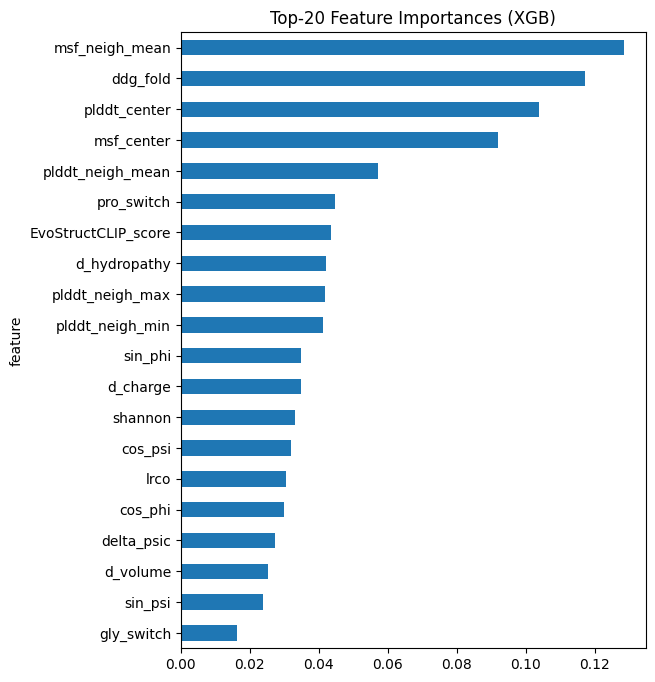

In [59]:
import matplotlib.pyplot as plt

topk = 20
imp_df.head(topk).plot(
    x="feature", y="importance", kind="barh",
    figsize=(6,8), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top-20 Feature Importances (XGB)")
plt.show()
